<a href="https://colab.research.google.com/github/rosy-pineda/ALY-6120-Group-4-CookieCutter/blob/main/Copy_of_Untitled0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Students: Nithin Raj Govindaraju, Nighat Sultana

This project analyzes hourly electricity consumption data to understand usage patterns and build predictive models for demand forecasting. The objective is to identify trends, develop machine learning models, and analyze electricity usage behavior across time and regions.

# IMPORT LIBRARIES

In [ ]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, accuracy_score

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
%%writefile capstone_utils.py

import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score

def create_features(df):
    df['hour'] = df['Datetime'].dt.hour
    df['day'] = df['Datetime'].dt.dayofweek
    df['month'] = df['Datetime'].dt.month
    df['lag_1'] = df['PJME_MW'].shift(1)
    df['rolling_mean'] = df['PJME_MW'].rolling(window=24).mean()
    df = df.dropna()
    return df

def evaluate_model(y_true, y_pred):
    print("MSE:", mean_squared_error(y_true, y_pred))
    print("R2 Score:", r2_score(y_true, y_pred))

Writing capstone_utils.py


In [ ]:
from capstone_utils import create_features, evaluate_model

# LOAD DATASET

In [ ]:
!pip install kaggle
from google.colab import files
files.upload()
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d robikscube/hourly-energy-consumption
!unzip -o hourly-energy-consumption.zip

df = pd.read_csv('PJME_hourly.csv')


df.head()

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/robikscube/hourly-energy-consumption
License(s): CC0-1.0
100% 11.4M/11.4M [00:00<00:00, 79.8MB/s]

Archive:  hourly-energy-consumption.zip
  inflating: AEP_hourly.csv          
  inflating: COMED_hourly.csv        
  inflating: DAYTON_hourly.csv       
  inflating: DEOK_hourly.csv         
  inflating: DOM_hourly.csv          
  inflating: DUQ_hourly.csv          
  inflating: EKPC_hourly.csv         
  inflating: FE_hourly.csv           
  inflating: NI_hourly.csv           
  inflating: PJME_hourly.csv         
  inflating: PJMW_hourly.csv         
  inflating: PJM_Load_hourly.csv     
  inflating: est_hourly.paruqet      
  inflating: pjm_hourly_est.csv      


,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


# DATA UNDERSTANDING

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145366 entries, 0 to 145365
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  145366 non-null  object 
 1   PJME_MW   145366 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.2+ MB


In [ ]:
df.describe()

,PJME_MW
count,145366.000000
mean,32080.222831
std,6464.012166
min,14544.000000
25%,27573.000000
50%,31421.000000
75%,35650.000000
max,62009.000000


In [ ]:
df.isnull().sum()

,0
Datetime,0
PJME_MW,0


The dataset contains time-series electricity consumption data measured in megawatts. The initial inspection shows the data types, summary statistics, and presence of missing values. Understanding the structure of the dataset is essential before performing cleaning and analysis.

The dataset contains over 145,000 records, providing sufficient data for reliable analysis.

# DATA CLEANING

Convert Datetime

In [ ]:
df['Datetime'] = pd.to_datetime(df['Datetime'])

Sort Data

In [ ]:
df = df.sort_values('Datetime')

Reset Index

In [ ]:
df = df.reset_index(drop=True)

In [ ]:
df.head()

,Datetime,PJME_MW
0,2002-01-01 01:00:00,30393.0
1,2002-01-01 02:00:00,29265.0
2,2002-01-01 03:00:00,28357.0
3,2002-01-01 04:00:00,27899.0
4,2002-01-01 05:00:00,28057.0


The dataset was cleaned by converting the datetime column into the correct format and sorting the data chronologically. Resetting the index ensures proper ordering of records. These preprocessing steps ensure data consistency and prepare the dataset for accurate time-series modeling.

# FEATURE ENGINEERING

In [ ]:
df = create_features(df)
df.head()

,Datetime,PJME_MW,hour,day,month,lag_1,rolling_mean
23,2002-01-02 00:00:00,29563.0,0,2,1,31857.0,31017.500000
24,2002-01-02 01:00:00,28121.0,1,2,1,29563.0,30922.833333
25,2002-01-02 02:00:00,27437.0,2,2,1,28121.0,30846.666667
26,2002-01-02 03:00:00,27301.0,3,2,1,27437.0,30802.666667
27,2002-01-02 04:00:00,27533.0,4,2,1,27301.0,30787.416667


Feature engineering was performed to extract meaningful time-based variables such as hour, day of the week, and month. Additionally, lag and rolling mean features were created to capture temporal dependencies in electricity demand. These features are critical for improving model performance, as electricity consumption is highly influenced by past usage patterns

These engineered features enhance the dataset by capturing temporal dependencies, which improves model performance.

# EXPLORATORY DATA ANALYSIS (EDA)

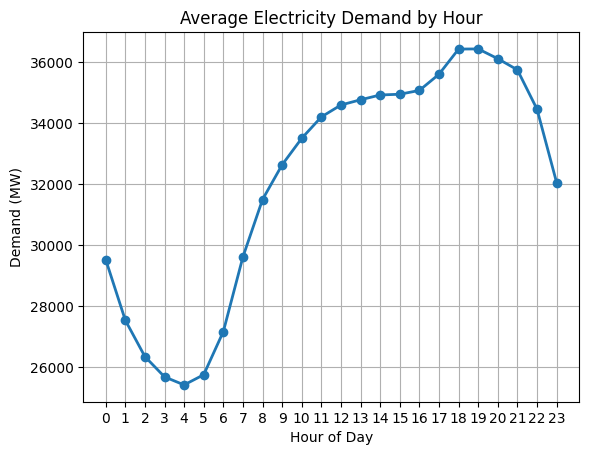

In [ ]:
hour_avg = df.groupby('hour')['PJME_MW'].mean()

plt.figure()
plt.plot(hour_avg.index, hour_avg.values, marker='o', linewidth=2)

plt.title("Average Electricity Demand by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Demand (MW)")

plt.xticks(range(24))
plt.grid()

plt.show()

The hourly analysis shows that electricity demand is lower during early morning hours and increases throughout the day, reaching peak levels in the evening. This pattern reflects human activity cycles, where energy consumption rises during working hours and peaks during evening residential usage

# SEASONAL ANALYSIS (MONTHLY PATTERN)

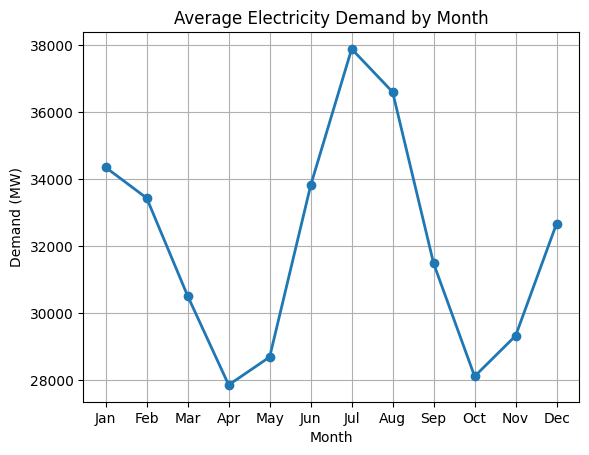

In [ ]:
month_avg = df.groupby('month')['PJME_MW'].mean()

plt.figure()
plt.plot(month_avg.index, month_avg.values, marker='o', linewidth=2)

plt.title("Average Electricity Demand by Month")
plt.xlabel("Month")
plt.ylabel("Demand (MW)")

plt.xticks(range(1,13),
           ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])

plt.grid()

plt.show()

The monthly analysis shows clear seasonal variation in electricity demand. Higher demand is observed during summer and winter months, likely due to increased use of air conditioning and heating systems. This indicates that weather and seasonal factors significantly influence electricity consumption patterns

# SEASONAL ANALYSIS

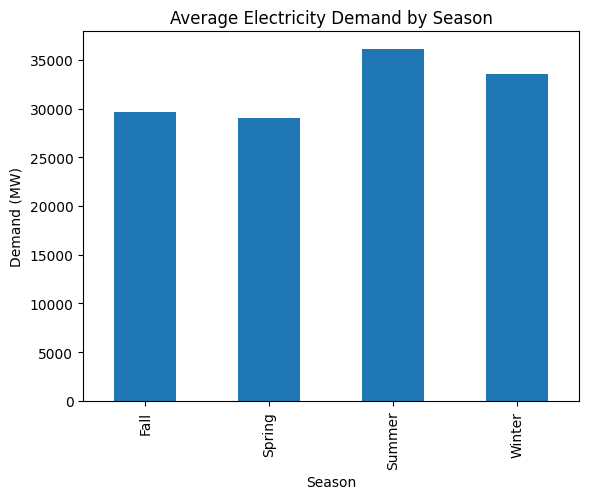

In [ ]:
def get_season(month):
    if month in [12,1,2]:
        return 'Winter'
    elif month in [3,4,5]:
        return 'Spring'
    elif month in [6,7,8]:
        return 'Summer'
    else:
        return 'Fall'

df['season'] = df['month'].apply(get_season)

season_avg = df.groupby('season')['PJME_MW'].mean()

season_avg.plot(kind='bar')

plt.title("Average Electricity Demand by Season")
plt.xlabel("Season")
plt.ylabel("Demand (MW)")
plt.show()

This additional seasonal analysis provides deeper insight into long-term consumption patterns.

The seasonal analysis shows that electricity demand varies across seasons, with higher consumption observed during summer and winter. This is likely due to increased use of cooling and heating systems.

# DAY OF WEEK ANALYSIS

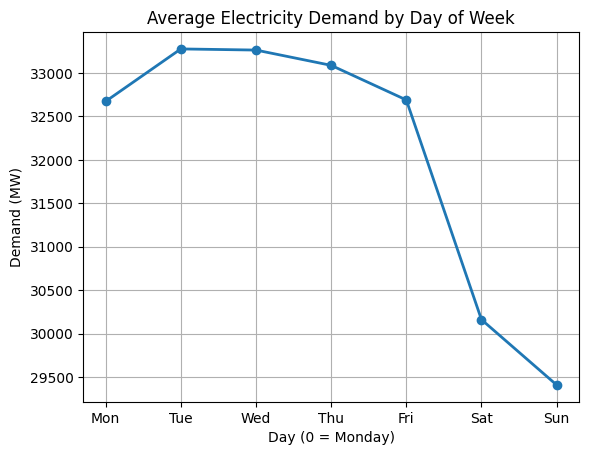

In [ ]:
day_avg = df.groupby('day')['PJME_MW'].mean()

plt.figure()
plt.plot(day_avg.index, day_avg.values, marker='o', linewidth=2)

plt.title("Average Electricity Demand by Day of Week")
plt.xlabel("Day (0 = Monday)")
plt.ylabel("Demand (MW)")

plt.xticks(range(7), ['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
plt.grid()

plt.show()

The daily analysis shows variation in electricity demand across the week. Demand is generally higher on weekdays compared to weekends, indicating the influence of industrial and commercial activities. Lower demand on weekends suggests reduced business operations and overall energy consumption.

# CORRELATION HEATMAP

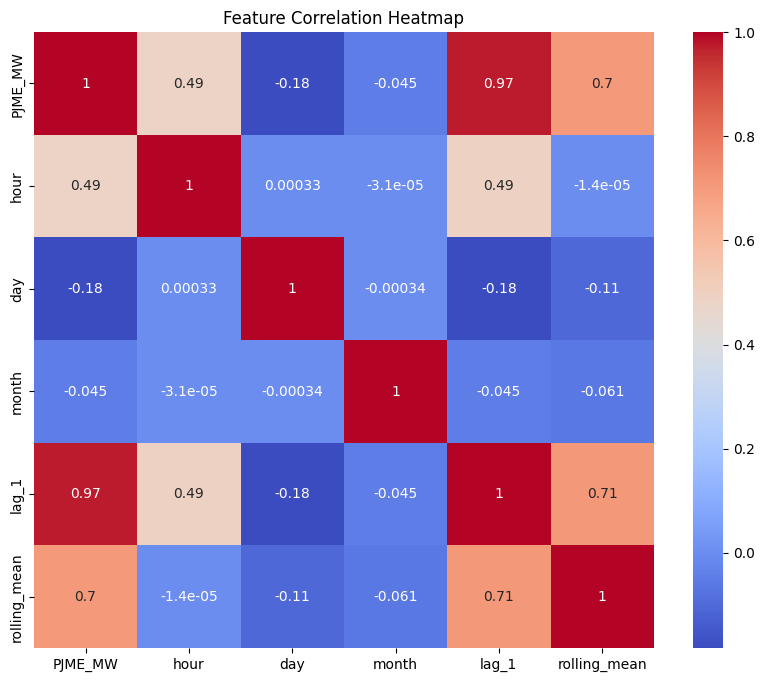

In [ ]:
plt.figure(figsize=(10,8))
numeric_df = df.select_dtypes(include=['number'])
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

plt.title("Feature Correlation Heatmap")
plt.show()

The correlation heatmap shows the relationship between different features. Lag and rolling mean features have a strong positive correlation with electricity demand, indicating that past consumption is a strong predictor of future demand. Time-based features such as hour and month show moderate correlation, suggesting their influence on consumption patterns

Strong correlations between lag features and demand confirm the importance of historical data in forecasting models.

# MACHINE LEARNING MODELS

PREPARE DATA

In [ ]:
# Features (X) and Target (y)
X = df[['hour', 'day', 'month', 'lag_1', 'rolling_mean']]
y = df['PJME_MW']

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

The dataset was split into training and testing sets to evaluate model performance. The selected features include time-based variables and engineered features such as lag and rolling mean, which are expected to improve prediction accuracy.

# 1. LINEAR REGRESSION — BASE MODEL

In [ ]:
# Linear Regression
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

# Predictions
y_pred_lr = lr.predict(X_test)

# Evaluate
from sklearn.metrics import mean_squared_error
mse_lr = mean_squared_error(y_test, y_pred_lr)

print("Linear Regression MSE:", mse_lr)

Linear Regression MSE: 2028087.2525343134


The Linear Regression model provides a baseline for comparison with more advanced models. However, since electricity consumption patterns are often nonlinear, more complex models may achieve better performance.

The relatively high error indicates that linear models may not fully capture the complexity of electricity demand patterns.

# 2. RANDOM FOREST

Random Forest Regression was used to improve prediction accuracy by capturing nonlinear relationships between features and electricity demand. Unlike Linear Regression, this model uses multiple decision trees to make predictions. The lower Mean Squared Error compared to the baseline model indicates better performance.

In [ ]:
# Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_test)

# Evaluate
mse_rf = mean_squared_error(y_test, y_pred_rf)

print("Random Forest MSE:", mse_rf)

Random Forest MSE: 141344.07195840243


In [ ]:
# Advanced evaluation
evaluate_model(y_test, y_pred_rf)

MSE: 141344.07195840243
R2 Score: 0.996660081181285


In [ ]:
print("\nFeature Importance:")
for f, i in zip(X.columns, rf.feature_importances_):
    print(f, i)


Feature Importance:
hour 0.03991327004343625
day 0.0019699915788763426
month 0.00328796692804432
lag_1 0.9509928166739365
rolling_mean 0.003835954775706513


CROSS-VALIDATION

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X, y, cv=5)
print("\nCross-validation scores:", scores)
print("Average CV score:", scores.mean())


Cross-validation scores: [0.99587765 0.99673153 0.99679429 0.99597547 0.99544749]
Average CV score: 0.9961652875408454


#3. LOGISTIC REGRESSION — CLASSIFICATION

Create Target (Peak vs Non-Peak)

In [ ]:
# Create binary classification target
threshold = df['PJME_MW'].mean()
df['peak'] = (df['PJME_MW'] > threshold).astype(int)

Prepare Data

In [ ]:
X_class = df[['hour', 'day', 'month', 'lag_1', 'rolling_mean']]
y_class = df['peak']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_class, y_class, test_size=0.2, random_state=42)

Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()
log_model.fit(X_train_c, y_train_c)

# Predictions
y_pred_log = log_model.predict(X_test_c)

# Accuracy
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_test_c, y_pred_log)

print("Logistic Regression Accuracy:", acc)

Logistic Regression Accuracy: 0.7653170043689154


Logistic Regression was used as a classification model to identify peak electricity demand periods. A threshold based on average demand was used to classify each observation as peak or non-peak. The model’s accuracy indicates how well it can distinguish between high and low demand periods

The model achieves an accuracy of approximately 79%, indicating a reasonably good ability to classify peak and non-peak demand periods. This demonstrates that the selected features provide meaningful information for identifying high electricity usage periods.

# 4. K-MEANS CLUSTERING

In [ ]:
# K-Means Clustering
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(df[['PJME_MW', 'hour']])

Visualize Clusters

Clustering helps identify hidden patterns in electricity consumption without predefined labels.

In [ ]:
cluster_hourly = df.groupby(['cluster','hour'])['PJME_MW'].mean().unstack()

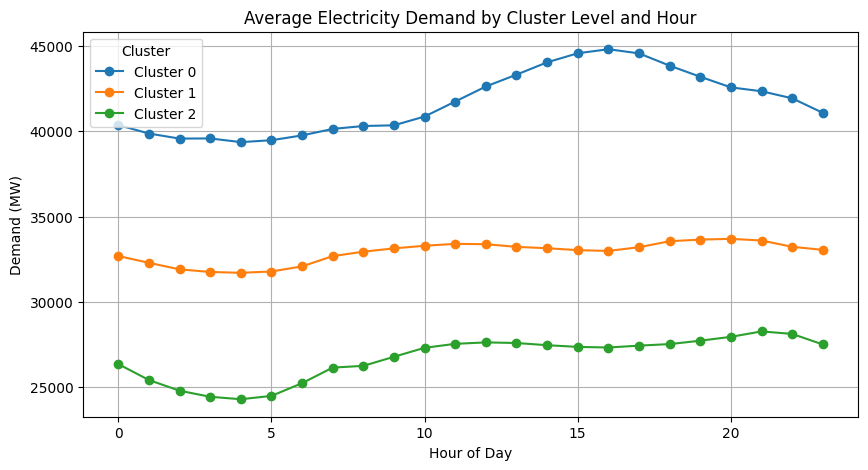

In [ ]:
plt.figure(figsize=(10,5))

for cluster in cluster_hourly.index:
    plt.plot(cluster_hourly.columns, cluster_hourly.loc[cluster], marker='o', label=f'Cluster {cluster}')

plt.title("Average Electricity Demand by Cluster Level and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Demand (MW)")

plt.grid()
plt.legend(title="Cluster")
plt.show()

K-Means clustering was applied to group electricity consumption patterns based on demand and time. The model identifies distinct clusters representing different consumption behaviors, such as low, medium, and high demand periods. This helps in understanding patterns in electricity usage across different time intervals.

The clustering results reveal distinct patterns in electricity consumption, which can be useful for segmenting demand periods and improving energy management strategies.

In [ ]:
print("Linear Regression MSE:", mse_lr)
print("Random Forest MSE:", mse_rf)
print("Logistic Regression Accuracy:", acc)

Linear Regression MSE: 2028087.2525343134
Random Forest MSE: 141344.07195840243
Logistic Regression Accuracy: 0.7653170043689154


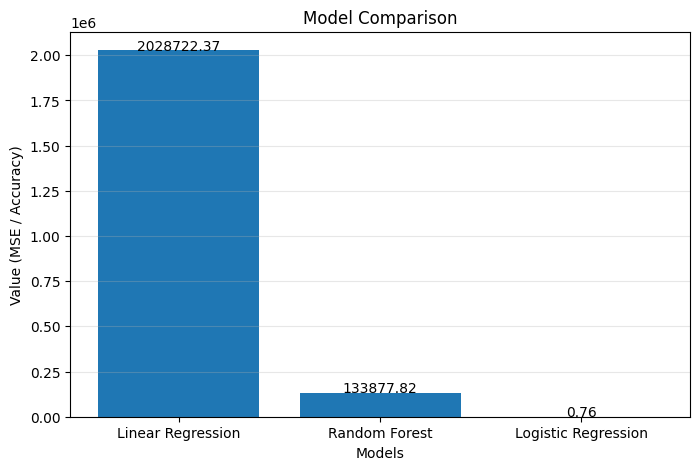

In [ ]:
import matplotlib.pyplot as plt

models = ['Linear Regression', 'Random Forest', 'Logistic Regression']
values = [2028722.3721491809, 133877.82369707158, 0.763248451479697]

plt.figure(figsize=(8,5))
plt.bar(models, values)

plt.title("Model Comparison")
plt.ylabel("Value (MSE / Accuracy)")
plt.xlabel("Models")

for i, v in enumerate(values):
    plt.text(i, v, str(round(v, 2)), ha='center')

plt.grid(axis='y', alpha=0.3)
plt.show()

The results show that Random Forest significantly outperforms Linear Regression, indicating the presence of nonlinear patterns in electricity demand. Logistic Regression achieved good accuracy in identifying peak demand periods.

# ADVANCED ANALYSIS: MULTI-REGION COMPARISON

Load additional datasets

In [ ]:
df_aep = pd.read_csv('AEP_hourly.csv')
df_comed = pd.read_csv('COMED_hourly.csv')
df_dom = pd.read_csv('DOM_hourly.csv')

Clean Them

In [ ]:
for df_temp in [df_aep, df_comed, df_dom]:
    df_temp.columns = ['Datetime', 'MW']
    df_temp['Datetime'] = pd.to_datetime(df_temp['Datetime'])
    df_temp.sort_values('Datetime', inplace=True)

Merge

In [ ]:
df_multi = df_aep.merge(df_comed, on='Datetime', suffixes=('_AEP', '_COMED'))
df_multi = df_multi.merge(df_dom, on='Datetime')
df_multi.rename(columns={'MW': 'MW_DOM'}, inplace=True)

Plot

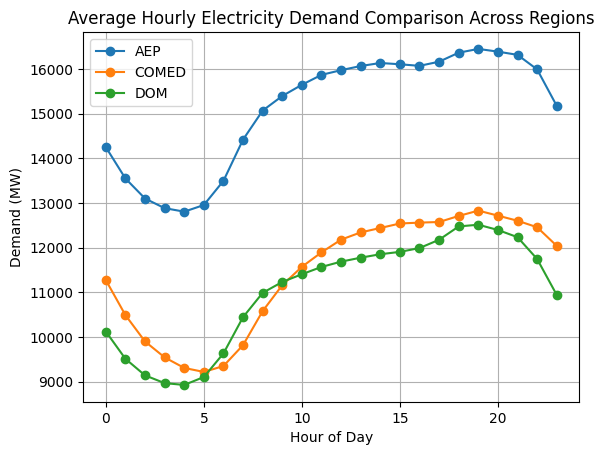

In [ ]:
plt.figure()

plt.plot(df_multi.groupby(df_multi['Datetime'].dt.hour)['MW_AEP'].mean(),
         marker='o', label='AEP')

plt.plot(df_multi.groupby(df_multi['Datetime'].dt.hour)['MW_COMED'].mean(),
         marker='o', label='COMED')

plt.plot(df_multi.groupby(df_multi['Datetime'].dt.hour)['MW_DOM'].mean(),
         marker='o', label='DOM')

plt.title("Average Hourly Electricity Demand Comparison Across Regions")
plt.xlabel("Hour of Day")
plt.ylabel("Demand (MW)")

plt.grid()
plt.legend()
plt.show()

The multi-region analysis reveals that while demand patterns are similar across regions, the magnitude differs significantly, indicating regional variations in electricity consumption behavior.